# Exercise 3

Use logistic regression to predict the probability of a passenger surviving.

https://www.kaggle.com/competitions/titanic/overview

In [113]:
import pandas as pd
from seaborn import load_dataset
from tabulate import tabulate  # pip install tabulate

df = load_dataset("titanic")

print(tabulate(df.head(), headers='keys', tablefmt='psql'))

+----+------------+----------+--------+-------+---------+---------+---------+------------+---------+-------+--------------+--------+---------------+---------+---------+
|    |   survived |   pclass | sex    |   age |   sibsp |   parch |    fare | embarked   | class   | who   | adult_male   | deck   | embark_town   | alive   | alone   |
|----+------------+----------+--------+-------+---------+---------+---------+------------+---------+-------+--------------+--------+---------------+---------+---------|
|  0 |          0 |        3 | male   |    22 |       1 |       0 |  7.25   | S          | Third   | man   | True         | nan    | Southampton   | no      | False   |
|  1 |          1 |        1 | female |    38 |       1 |       0 | 71.2833 | C          | First   | woman | False        | C      | Cherbourg     | yes     | False   |
|  2 |          1 |        3 | female |    26 |       0 |       0 |  7.925  | S          | Third   | woman | False        | nan    | Southampton   | yes   

In [114]:
# Select relevant columns
df = df.loc[:, ['survived', 'age', 'sex', 'pclass']]

# Drop rows with missing values before encoding to avoid errors
df.dropna(inplace=True)

# Convert categorical variables into dummy/indicator variables
df = pd.get_dummies(df, columns=['sex', 'pclass'], drop_first=True)

# Show the first few rows
df.head()

,survived,age,sex_male,pclass_2,pclass_3
0,0,22.0,True,False,True
1,1,38.0,False,False,False
2,1,26.0,False,False,True
3,1,35.0,False,False,False
4,0,35.0,True,False,True


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  714 non-null    int64  
 1   age       714 non-null    float64
 2   sex_male  714 non-null    bool   
 3   pclass_2  714 non-null    bool   
 4   pclass_3  714 non-null    bool   
dtypes: bool(3), float64(1), int64(1)
memory usage: 18.8 KB


In [116]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop('survived', axis=1)
y = df['survived']

# Split dataset into train and test sets with stratification and shuffling
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42,
    shuffle=True
)

In [117]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=0,
    max_iter=200,
    solver='liblinear',
    penalty='l2',
    C=1.0
)

# Fit the model on training data
model.fit(X_train, y_train)

LogisticRegression(max_iter=200, random_state=0, solver='liblinear')

In [118]:
print(f"Accuracy: {model.score(X_test, y_test):.3f}")

Accuracy: 0.788


In [119]:
from sklearn.model_selection import cross_val_score

print(cross_val_score(model, X, y, cv=5).mean())

0.7871466561607406


In [120]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))

[[90 16]
 [22 51]]


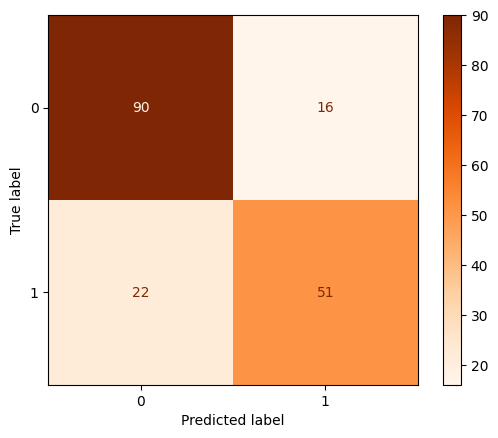

In [121]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test) # Generate predictions for the test set
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Oranges)
plt.show()

In [122]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.85      0.83       106
           1       0.76      0.70      0.73        73

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179



In [123]:
female = [[30, 0, 0, 0]]
print(model.predict(female)[0])

1


In [124]:
prob = model.predict_proba(female)[0, 1]
print(f'Survival Probability: {prob:.1%}')

Survival Probability: 88.8%


In [125]:
male = [[60, 1, 0, 0]]

prob = model.predict_proba(male)[0, 1]
print(f'Survival Probability: {prob:.1%}')



Survival Probability: 27.6%


## Dataset File

In [126]:
dataset_url = 'https://github.com/robitussin/CCMACLRL_EXERCISES_OLD/blob/f5fdfba1aabbbafcf2fe49ca6e1c8f92f69d1458/datasets/titanic/train.csv?raw=true'
df = pd.read_csv(dataset_url)

## Test File

In [127]:
test_url = 'https://github.com/robitussin/CCMACLRL_EXERCISES_OLD/blob/f5fdfba1aabbbafcf2fe49ca6e1c8f92f69d1458/datasets/titanic/test.csv?raw=true'
dt=pd.read_csv(test_url)

In [128]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


## Sample Submission File

In [129]:
sample_submission_url ='https://github.com/robitussin/CCMACLRL_EXERCISES_OLD/blob/f5fdfba1aabbbafcf2fe49ca6e1c8f92f69d1458/datasets/titanic/gender_submission.csv?raw=true'

sf=pd.read_csv(sample_submission_url)

In [130]:
sf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB


## Generate Results

In [133]:
# Select relevant columns
dt_processed = dt.loc[:, ['PassengerId', 'Age', 'Sex', 'Pclass']]

# Fill missing values instead of dropping (keep 418 rows!)
dt_processed['Age'] = dt_processed['Age'].fillna(dt_processed['Age'].median())

# Save PassengerIds for submission
processed_ids = dt_processed['PassengerId']
dt_processed = dt_processed.drop('PassengerId', axis=1)

# Convert categorical variables into dummy/indicator variables
dt_processed = pd.get_dummies(dt_processed, columns=['Sex', 'Pclass'], drop_first=True)

# Align columns with training data
missing_cols = set(X_train.columns) - set(dt_processed.columns)
for c in missing_cols:
    dt_processed[c] = 0

# Ensure the same column order as training
dt_processed = dt_processed[X_train.columns]

# Predict with trained model
y_pred = model.predict(dt_processed)

# Create submission DataFrame
submission_df = pd.DataFrame({
    'PassengerId': processed_ids,
    'Survived': y_pred
})

# Save submission file
submission_df.to_csv('submission_file.csv', index=False)
print("✅ Submission file created: submission_file.csv")
print("Rows in submission:", submission_df.shape[0])


✅ Submission file created: submission_file.csv
Rows in submission: 418
